In [2]:
# --- Cell 1: Impor Library & Cek Instalasi ---
print("Mencoba mengimpor semua library...")
try:
    # 1. Library Dasar
    import pandas as pd
    import numpy as np
    
    # 2. Library Visualisasi
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # 3. Library Scikit-Learn (untuk ML)
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score
    
    # 4. Library Imbalanced-Learn (untuk SMOTE)
    from imblearn.over_sampling import SMOTE
    
    # 5. Model ML
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.neural_network import MLPClassifier # Artificial Neural Network

    # Mengatur display pandas agar semua kolom terlihat
    pd.set_option('display.max_columns', None)
    pd.set_option('display.max_rows', None)

    print("--- SUKSES ---")
    print("Semua library berhasil diimpor dan siap digunakan.")

except ImportError as e:
    print(f"--- ERROR ---")
    print(f"Gagal mengimpor: {e}")
    print("Pastikan Anda sudah menjalankan instalasi dengan benar (lihat kode !pip install ... di atas).")

Mencoba mengimpor semua library...
--- SUKSES ---
Semua library berhasil diimpor dan siap digunakan.


In [3]:
# --- Cell 2: Memuat dan Membersihkan Data ---

file_path = 'data-bank.csv' 
df = pd.read_csv(file_path)



In [4]:
print(df.head())

   Bankrupt?   ROA(C) before interest and depreciation before interest  \
0          1                                           0.370594          
1          1                                           0.464291          
2          1                                           0.426071          
3          1                                           0.399844          
4          1                                           0.465022          

    ROA(A) before interest and % after tax  \
0                                 0.424389   
1                                 0.538214   
2                                 0.499019   
3                                 0.451265   
4                                 0.538432   

    ROA(B) before interest and depreciation after tax  \
0                                           0.405750    
1                                           0.516730    
2                                           0.472295    
3                                           0.4577

In [5]:
# Data Cleaning: Membersihkan spasi di awal/akhir nama kolom
df.columns = df.columns.str.strip()

print(f"Data '{file_path}' berhasil dimuat.")
print("Nama kolom telah dirapikan.")
print("\n--- 5 Baris Pertama Data ---")
print(df.head())

# (Opsional) Cek info untuk memastikan tidak ada nilai null
df.info()

Data 'data-bank.csv' berhasil dimuat.
Nama kolom telah dirapikan.

--- 5 Baris Pertama Data ---
   Bankrupt?  ROA(C) before interest and depreciation before interest  \
0          1                                           0.370594         
1          1                                           0.464291         
2          1                                           0.426071         
3          1                                           0.399844         
4          1                                           0.465022         

   ROA(A) before interest and % after tax  \
0                                0.424389   
1                                0.538214   
2                                0.499019   
3                                0.451265   
4                                0.538432   

   ROA(B) before interest and depreciation after tax  Operating Gross Margin  \
0                                           0.405750                0.601457   
1                                 

--- Distribusi Target Variable (Bankrupt?) ---
Bankrupt?
0    6599
1     220
Name: count, dtype: int64


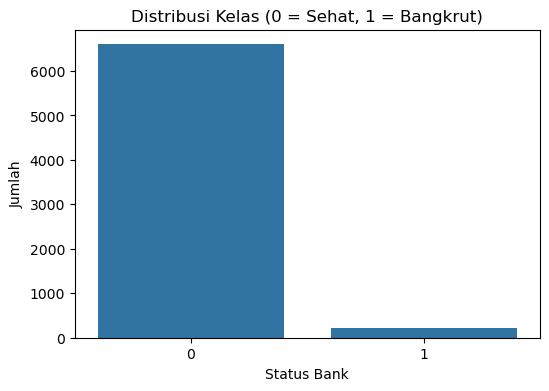


Checkpoint: Terlihat jelas data sangat tidak seimbang (imbalanced).


In [6]:
# --- Cell 3: Data Understanding (Cek Imbalance) ---

# Tentukan nama kolom target
target_variable = 'Bankrupt?'

print(f"--- Distribusi Target Variable ({target_variable}) ---")
print(df[target_variable].value_counts())

# Visualisasi
plt.figure(figsize=(6, 4))
sns.countplot(x=target_variable, data=df)
plt.title('Distribusi Kelas (0 = Sehat, 1 = Bangkrut)')
plt.xlabel('Status Bank')
plt.ylabel('Jumlah')
plt.show()

print("\nCheckpoint: Terlihat jelas data sangat tidak seimbang (imbalanced).")

In [7]:
# --- Cell 4: Data Preparation (Fitur, Target, dan Scaling) ---

# Memisahkan Fitur (X) dan Target (y)
X = df.drop(target_variable, axis=1)
y = df[target_variable]

# Menyimpan nama fitur untuk Laporan Variabel Penting (Langkah 6 PDF)
feature_names = X.columns.tolist()

# Data Transformation: Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Checkpoint: Data telah dipisah menjadi X (fitur) dan y (target).")
print("Fitur X juga telah di-scaling.")

Checkpoint: Data telah dipisah menjadi X (fitur) dan y (target).
Fitur X juga telah di-scaling.


In [8]:
# --- Cell 5: Data Preparation (Split Data Training & Testing) ---

# Split data (80% train, 20% test)
# 'stratify=y' memastikan proporsi bangkrut/sehat di train dan test sama
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("Checkpoint: Data telah dibagi menjadi set Training dan Testing.")
print(f"Bentuk X_train: {X_train.shape}")
print(f"Bentuk X_test: {X_test.shape}")
print(f"\nJumlah 'Bankrupt' (1) di data Latihan (sebelum SMOTE): {sum(y_train == 1)}")

Checkpoint: Data telah dibagi menjadi set Training dan Testing.
Bentuk X_train: (5455, 95)
Bentuk X_test: (1364, 95)

Jumlah 'Bankrupt' (1) di data Latihan (sebelum SMOTE): 176


In [9]:
# --- Cell 6: Data Preparation (Menangani Imbalance dengan SMOTE) ---

print("--- Menjalankan SMOTE ---")
smote = SMOTE(random_state=42)

# Kita 'fit_resample' HANYA pada data training
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("--- SMOTE Selesai ---")
print("Bentuk Data Latihan (setelah SMOTE):")
print(f"X_train_smote: {X_train_smote.shape}")

print("\nDistribusi Data Latihan (setelah SMOTE):")
print(y_train_smote.value_counts())

print("\nCheckpoint: Data Latihan SEKARANG sudah seimbang (balance).")

--- Menjalankan SMOTE ---
--- SMOTE Selesai ---
Bentuk Data Latihan (setelah SMOTE):
X_train_smote: (10558, 95)

Distribusi Data Latihan (setelah SMOTE):
Bankrupt?
0    5279
1    5279
Name: count, dtype: int64

Checkpoint: Data Latihan SEKARANG sudah seimbang (balance).


In [10]:
# --- Cell 7: Modelling (Melatih 3 Algoritma) ---

print("--- Memulai Pelatihan Model ---")

# 1. Definisikan Model
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Artificial Neural Network": MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
}

# 2. Latih Setiap Model
# (ANN mungkin butuh waktu beberapa saat)
for name, model in models.items():
    print(f"Melatih {name}...")
    # Latih dengan data SMOTE
    model.fit(X_train_smote, y_train_smote)

print("\nCheckpoint: Semua 3 model telah selesai dilatih.")

--- Memulai Pelatihan Model ---
Melatih Decision Tree...
Melatih Random Forest...
Melatih Artificial Neural Network...

Checkpoint: Semua 3 model telah selesai dilatih.


In [11]:
# --- Cell 8: Evaluation (Membandingkan Performa Model) ---

results = {}
best_model_name = ""
best_model_instance = None
best_recall_score = -1

print("--- Hasil Evaluasi pada Data Test ---")

for name, model in models.items():
    # Buat prediksi pada data test
    y_pred = model.predict(X_test)
    
    print(f"\n==================== EVALUASI: {name} ====================")
    
    # Tampilkan Confusion Matrix
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    # Tampilkan Classification Report (Precision, Recall, F1-Score)
    print("\nClassification Report:")
    report = classification_report(y_test, y_pred, target_names=['Sehat (0)', 'Bangkrut (1)'])
    print(report)
    
    # Hitung Recall spesifik untuk kelas 1 (Bangkrut)
    recall_bangkrut = recall_score(y_test, y_pred, pos_label=1) 
    results[name] = {'recall_bangkrut': recall_bangkrut, 'model': model}
    
    # Simpan model terbaik (berdasarkan Recall 'Bangkrut')
    if recall_bangkrut > best_recall_score:
        best_recall_score = recall_bangkrut
        best_model_name = name
        best_model_instance = model

print("\nCheckpoint: Evaluasi selesai.")

--- Hasil Evaluasi pada Data Test ---

==================== EVALUASI: Decision Tree ====================
Confusion Matrix:
[[1244   76]
 [  21   23]]

Classification Report:
              precision    recall  f1-score   support

   Sehat (0)       0.98      0.94      0.96      1320
Bangkrut (1)       0.23      0.52      0.32        44

    accuracy                           0.93      1364
   macro avg       0.61      0.73      0.64      1364
weighted avg       0.96      0.93      0.94      1364


==================== EVALUASI: Random Forest ====================
Confusion Matrix:
[[1285   35]
 [  17   27]]

Classification Report:
              precision    recall  f1-score   support

   Sehat (0)       0.99      0.97      0.98      1320
Bangkrut (1)       0.44      0.61      0.51        44

    accuracy                           0.96      1364
   macro avg       0.71      0.79      0.74      1364
weighted avg       0.97      0.96      0.96      1364


==================== EVALUASI: Arti

In [12]:
# --- Cell 9: Hasil Akhir (Model Terbaik) ---

print("--- Perbandingan Model ---")
print(f"Model Terbaik (berdasarkan Recall 'Bangkrut'): {best_model_name}")
print(f"Skor Recall 'Bangkrut' Tertinggi: {best_recall_score:.4f}")

print("\nInterpretasi:")
print(f"Model '{best_model_name}' adalah yang paling 'jago' dalam menemukan bank")
print("yang terancam bangkrut (kelas 1) di antara data yang ada.")

--- Perbandingan Model ---
Model Terbaik (berdasarkan Recall 'Bangkrut'): Random Forest
Skor Recall 'Bangkrut' Tertinggi: 0.6136

Interpretasi:
Model 'Random Forest' adalah yang paling 'jago' dalam menemukan bank
yang terancam bangkrut (kelas 1) di antara data yang ada.


In [13]:
# --- Cell 10: Interpretasi (5 Variabel Paling Berpengaruh) ---

print("--- 5 Variabel Paling Berpengaruh (Feature Importance) ---")

importance_model = None

# Cek apakah model terbaik adalah ANN
if best_model_name == "Artificial Neural Network":
    print("ANN tidak menyediakan feature importance secara langsung.")
    print("Menggunakan 'Random Forest' sebagai proxy untuk interpretasi...")
    # Kita gunakan model Random Forest yang sudah dilatih (dari 'models')
    importance_model = models["Random Forest"]
else:
    # Gunakan model terbaik (Decision Tree atau Random Forest)
    importance_model = best_model_instance

try:
    # Dapatkan skor kepentingan dari model
    importances = importance_model.feature_importances_
    
    # Buat series pandas untuk mempermudah visualisasi
    feature_importance_series = pd.Series(importances, index=feature_names)
    
    # Mengurutkan dan mengambil 5 teratas
    top_5_features = feature_importance_series.nlargest(5)
    
    print("\n5 Indikator Teratas yang Mempengaruhi Kebangkrutan:")
    print(top_5_features)

except AttributeError:
    print(f"Model {best_model_name} tidak memiliki atribut 'feature_importances_'.")

--- 5 Variabel Paling Berpengaruh (Feature Importance) ---

5 Indikator Teratas yang Mempengaruhi Kebangkrutan:
Borrowing dependency                       0.083886
Liability to Equity                        0.051615
Net Income to Total Assets                 0.050565
Debt ratio %                               0.042066
Persistent EPS in the Last Four Seasons    0.041178
dtype: float64


In [14]:
# --- Cell 1: Preprocessing (Seleksi Fitur Teratas) ---

print("--- Memulai Preprocessing Lanjutan: Feature Selection ---")

# 1. Pastikan data 'df' (dataframe asli) ada
try:
    if 'df' not in locals():
        print("Memuat ulang data 'data-bank.csv'...")
        df = pd.read_csv('data-bank.csv')
        df.columns = df.columns.str.strip()
except Exception as e:
    print(f"Error saat memuat data: {e}")
    
# 2. Ambil 30 fitur teratas dari model Random Forest (dari cell 7 & 8)
try:
    # Ambil model RF yang sudah dilatih
    baseline_model = models["Random Forest"]
    
    # Buat series feature importance
    importances = baseline_model.feature_importances_
    feature_importance_series = pd.Series(importances, index=feature_names)
    
    # Ambil 30 nama fitur teratas
    n_features_to_select = 30
    top_features = feature_importance_series.nlargest(n_features_to_select)
    top_feature_names = top_features.index.tolist()
    
    print(f"Berhasil mengidentifikasi {len(top_feature_names)} fitur teratas.")
    print("5 Fitur Teratas:")
    print(top_features.head())

    # 3. Buat dataset X dan y yang BARU
    X_selected = df[top_feature_names]
    y_selected = df[target_variable] # y tetap sama

    print(f"\nBentuk X (fitur) baru: {X_selected.shape}")
    print(f"Bentuk y (target) baru: {y_selected.shape}")

except NameError as e:
    print(f"ERROR: Variabel '{e.name}' tidak ditemukan.")
    print("Pastikan Anda sudah menjalankan Cell 7 dan Cell 10 (dari kode sebelumnya) agar 'models' dan 'feature_names' ada di memori.")

--- Memulai Preprocessing Lanjutan: Feature Selection ---
Berhasil mengidentifikasi 30 fitur teratas.
5 Fitur Teratas:
Borrowing dependency                       0.083886
Liability to Equity                        0.051615
Net Income to Total Assets                 0.050565
Debt ratio %                               0.042066
Persistent EPS in the Last Four Seasons    0.041178
dtype: float64

Bentuk X (fitur) baru: (6819, 30)
Bentuk y (target) baru: (6819,)


In [15]:
# --- Cell 2: Ulangi Pipeline (Scale, Split, SMOTE) ---

print("--- Menjalankan pipeline preprocessing pada data terseleksi ---")

# 1. Scaling data X yang baru (30 fitur)
scaler_sel = StandardScaler()
X_sel_scaled = scaler_sel.fit_transform(X_selected)

# 2. Split data (80% train, 20% test)
# Gunakan y_selected dan 'stratify=y_selected'
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_sel_scaled, y_selected, test_size=0.2, random_state=42, stratify=y_selected
)

# 3. Terapkan SMOTE (HANYA pada data training)
smote_sel = SMOTE(random_state=42)
X_train_smote_sel, y_train_smote_sel = smote_sel.fit_resample(X_train_sel, y_train_sel)

print("Checkpoint: Pipeline preprocessing untuk data terseleksi selesai.")
print(f"Bentuk X_train (SMOTE, 30 fitur): {X_train_smote_sel.shape}")
print(f"Bentuk X_test (30 fitur): {X_test_sel.shape}")

--- Menjalankan pipeline preprocessing pada data terseleksi ---
Checkpoint: Pipeline preprocessing untuk data terseleksi selesai.
Bentuk X_train (SMOTE, 30 fitur): (10558, 30)
Bentuk X_test (30 fitur): (1364, 30)


In [16]:
# --- Cell 3: Latih Model XGBoost (Optimasi) ---

# Pastikan Anda sudah menginstal xgboost (!pip install xgboost)
try:
    from xgboost import XGBClassifier
except ImportError:
    print("Error: Library xgboost belum terinstal. Jalankan '!pip install xgboost' di cell baru.")

print("--- Melatih Model XGBoost pada 30 Fitur Terpilih ---")

# Definisikan model
model_xgb_opt = XGBClassifier(
    random_state=42, 
    n_estimators=100,      # Anda bisa tingkatkan ini (misal 200)
    use_label_encoder=False, 
    eval_metric='logloss'
)

# Latih model
model_xgb_opt.fit(X_train_smote_sel, y_train_smote_sel)

print("--- Model XGBoost (Optimasi) selesai dilatih. ---")

--- Melatih Model XGBoost pada 30 Fitur Terpilih ---


C:\Users\Lenovo\anaconda3\envs\ai_env\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:15:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- Model XGBoost (Optimasi) selesai dilatih. ---


In [17]:
# --- Cell 4: Evaluasi Model XGBoost (Optimasi) ---

print("--- Evaluasi Model XGBoost (Optimasi) pada Data Test ---")

# Buat prediksi pada data test yang baru (X_test_sel)
y_pred_xgb_opt = model_xgb_opt.predict(X_test_sel)

# Tampilkan Confusion Matrix
print("\nConfusion Matrix (XGBoost Optimasi):")
# y_test_sel adalah data aktual dari split yang baru
print(confusion_matrix(y_test_sel, y_pred_xgb_opt))

# Tampilkan Classification Report
print("\nClassification Report (XGBoost Optimasi):")
report_xgb_opt = classification_report(
    y_test_sel, 
    y_pred_xgb_opt, 
    target_names=['Sehat (0)', 'Bangkrut (1)']
)
print(report_xgb_opt)

--- Evaluasi Model XGBoost (Optimasi) pada Data Test ---

Confusion Matrix (XGBoost Optimasi):
[[1277   43]
 [  17   27]]

Classification Report (XGBoost Optimasi):
              precision    recall  f1-score   support

   Sehat (0)       0.99      0.97      0.98      1320
Bangkrut (1)       0.39      0.61      0.47        44

    accuracy                           0.96      1364
   macro avg       0.69      0.79      0.73      1364
weighted avg       0.97      0.96      0.96      1364



In [18]:
# --- Cell 1: Impor & Persiapan Tuning ---

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score, make_scorer

# 1. Tentukan "kisi" parameter untuk dicoba
# Ini adalah daftar pengaturan yang kita ingin uji
param_dist = {
    'n_estimators': [100, 200, 300, 500], # Jumlah pohon di hutan
    'max_depth': [10, 20, 30, None],       # Kedalaman maksimum pohon
    'min_samples_split': [2, 5, 10],      # Jumlah minimum sampel untuk membelah node
    'min_samples_leaf': [1, 2, 4],        # Jumlah minimum sampel di daun
    'bootstrap': [True, False]            # Apakah sampel diambil dengan replacement
}

# 2. Buat model dasar
# Ini adalah model yang akan kita "tuning"
rf_base = RandomForestClassifier(random_state=42)

# 3. Tentukan metrik skor kita
# Kita ingin mengoptimalkan F1-score untuk kelas 1 (Bangkrut)
# karena itu adalah metrik yang seimbang (Precision + Recall)
f1_scorer_bangkrut = make_scorer(f1_score, pos_label=1)

print("Checkpoint: Parameter grid dan scorer untuk tuning sudah siap.")

Checkpoint: Parameter grid dan scorer untuk tuning sudah siap.


In [19]:
# --- Cell 2: Jalankan RandomizedSearchCV ---

print("--- Memulai Hyperparameter Tuning untuk Random Forest ---")
print("Ini mungkin memakan waktu beberapa menit...")

# Inisialisasi RandomizedSearch
# n_iter=50: Coba 50 kombinasi acak
# cv=3: Gunakan 3-fold cross-validation
# scoring: Optimalkan berdasarkan skor f1 untuk kelas 'Bangkrut (1)'
# n_jobs=-1: Gunakan semua core CPU Anda agar lebih cepat
rf_random = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=50,  # Coba 50 kombinasi. Bisa diturunkan ke 20-30 jika terlalu lama
    cv=3,
    scoring=f1_scorer_bangkrut, 
    verbose=2, # Menampilkan progres
    random_state=42,
    n_jobs=-1
)

# Latih pencarian pada data SMOTE yang asli (dengan semua fitur)
# (Kita asumsikan data 'X_train_smote' dan 'y_train_smote' dari Cell 6 masih ada)
try:
    rf_random.fit(X_train_smote, y_train_smote)
    print("\n--- Tuning Selesai ---")
except NameError:
    print("\n--- ERROR ---")
    print("Variabel 'X_train_smote' tidak ditemukan.")
    print("Harap jalankan ulang Cell 1 s/d 6 (dari kode awal) untuk membuatnya.")

--- Memulai Hyperparameter Tuning untuk Random Forest ---
Ini mungkin memakan waktu beberapa menit...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

--- Tuning Selesai ---


In [20]:
# --- Cell 3: Tampilkan Hasil Tuning & Evaluasi ---

try:
    # 1. Tampilkan pengaturan (hyperparameter) terbaik yang ditemukan
    print("--- Pengaturan Terbaik Ditemukan ---")
    print(rf_random.best_params_)

    # 2. Ambil model terbaik
    best_rf_model = rf_random.best_estimator_

    # 3. Evaluasi model terbaik ini pada data Test
    print("\n--- Evaluasi Model Random Forest (Hasil Tuning) ---")
    
    # Gunakan data X_test yang asli (dari Cell 5)
    y_pred_rf_tuned = best_rf_model.predict(X_test)

    # Tampilkan Confusion Matrix
    print("\nConfusion Matrix (RF Tuned):")
    print(confusion_matrix(y_test, y_pred_rf_tuned))

    # Tampilkan Classification Report
    print("\nClassification Report (RF Tuned):")
    report_rf_tuned = classification_report(
        y_test, 
        y_pred_rf_tuned, 
        target_names=['Sehat (0)', 'Bangkrut (1)']
    )
    print(report_rf_tuned)

except Exception as e:
    print(f"Error: {e}. Pastikan Cell 2 (tuning) berjalan sukses.")

--- Pengaturan Terbaik Ditemukan ---
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None, 'bootstrap': False}

--- Evaluasi Model Random Forest (Hasil Tuning) ---

Confusion Matrix (RF Tuned):
[[1294   26]
 [  22   22]]

Classification Report (RF Tuned):
              precision    recall  f1-score   support

   Sehat (0)       0.98      0.98      0.98      1320
Bangkrut (1)       0.46      0.50      0.48        44

    accuracy                           0.96      1364
   macro avg       0.72      0.74      0.73      1364
weighted avg       0.97      0.96      0.97      1364

